> #### Environment Setup
> Copy the following line to the terminal
> ```cmd
> pip install matplotlib numpy scipy scikit-learn tensorflow yfinance
> ```

# Plan
1. Fetch Data
2. Generate All Candidate Features (technical indicators, returns, ratios, time)
3. Forward Selection — find the best feature subset
4. Data Preparation — selected features, train/test split **before** scaling, RobustScaler
5. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
6. Predict & Visualize
7. Evaluate — RMSE, MAE, MAPE

---
# 1. Fetching Stock Data

In [1]:
import yfinance as yf

stock_data = yf.download('TSLA', start='2016-01-01', multi_level_index=False)
stock_data

/tmp/ipykernel_4031/1221156776.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('TSLA', start='2016-01-01', multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,14.894000,15.425333,14.600000,15.381333,102406500
2016-01-05,14.895333,15.126000,14.666667,15.090667,47802000
2016-01-06,14.602667,14.670000,14.398667,14.666667,56686500
2016-01-07,14.376667,14.562667,14.244667,14.279333,53314500
2016-01-08,14.066667,14.696000,14.051333,14.524000,54421500
...,...,...,...,...,...
2026-03-25,385.950012,396.230011,385.010010,389.989990,55157300
2026-03-26,372.109985,384.440002,371.869995,381.600006,55522900
2026-03-27,361.829987,369.859985,359.470001,369.690002,62065700


---
# 2. Generate All Candidate Features

In [2]:
import numpy as np
import pandas as pd
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = stock_data.copy()

# --- Technical indicators ---
for w in [5, 10, 20, 50]:
    df[f'SMA_{w}']    = df['Close'].rolling(w).mean()
    df[f'EMA_{w}']    = df['Close'].ewm(span=w).mean()
    df[f'Volatility_{w}'] = df['Close'].pct_change().rolling(w).std()

df['RSI_14'] = 100 - 100 / (1 + df['Close'].diff().clip(lower=0).rolling(14).mean() /
                             df['Close'].diff().clip(upper=0).abs().rolling(14).mean())

ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD']         = ema12 - ema26
df['MACD_signal']  = df['MACD'].ewm(span=9).mean()
df['MACD_hist']    = df['MACD'] - df['MACD_signal']

sma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = sma20 + 2 * std20
df['BB_lower'] = sma20 - 2 * std20
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / sma20

high_low  = df['High'] - df['Low']
high_prev = (df['High'] - df['Close'].shift(1)).abs()
low_prev  = (df['Low']  - df['Close'].shift(1)).abs()
df['ATR_14'] = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1).rolling(14).mean()

df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).cumsum()

# --- Returns ---
df['log_return']   = np.log(df['Close'] / df['Close'].shift(1))
df['return_1d']    = df['Close'].pct_change()
df['return_5d']    = df['Close'].pct_change(5)

# --- Price ratios ---
df['high_low_ratio']  = df['High'] / df['Low']
df['close_open_ratio'] = df['Close'] / df['Open']

# --- Time features ---
year_days = df.index.is_leap_year * 366 + (~df.index.is_leap_year) * 365
df['sin_year'] = np.sin(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['cos_year'] = np.cos(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['day_of_week'] = df.index.dayofweek / 6.0

# --- Target ---
df['Close_nxt'] = df['Close'].shift(-1)
df = df.dropna()

ALL_FEATURES = [c for c in df.columns if c not in ['Close_nxt']]
print(f"{len(ALL_FEATURES)} candidate features:\n{ALL_FEATURES}")

34 candidate features:
['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_5', 'EMA_5', 'Volatility_5', 'SMA_10', 'EMA_10', 'Volatility_10', 'SMA_20', 'EMA_20', 'Volatility_20', 'SMA_50', 'EMA_50', 'Volatility_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'log_return', 'return_1d', 'return_5d', 'high_low_ratio', 'close_open_ratio', 'sin_year', 'cos_year', 'day_of_week']


---
# 3. Forward Feature Selection
Evaluate each feature alone, then greedily add the feature that reduces validation MSE the most.

In [3]:
from sklearn.preprocessing import RobustScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping

LOOKBACK = 60
TRAIN_RATIO = 0.8
SEL_EPOCHS = 50
SEL_PATIENCE = 8

_split = int(len(df) * TRAIN_RATIO)

def _make_seq(f, t, lb):
    X, y = [], []
    for i in range(lb, len(f)):
        X.append(f[i-lb:i])
        y.append(t[i, 0])
    return np.array(X), np.array(y)

def evaluate_feature_set(feature_cols, verbose=0):
    """Train LSTM on given features, return test MSE."""
    scaler_f = RobustScaler()
    scaler_t = RobustScaler()

    train_f = scaler_f.fit_transform(df[feature_cols].values[:_split])
    test_f  = scaler_f.transform(df[feature_cols].values[_split:])
    train_t = scaler_t.fit_transform(df[['Close_nxt']].values[:_split])
    test_t  = scaler_t.transform(df[['Close_nxt']].values[_split:])

    X_tr, y_tr = _make_seq(train_f, train_t, LOOKBACK)
    padded_f = np.concatenate([train_f[-LOOKBACK:], test_f])
    padded_t = np.concatenate([train_t[-LOOKBACK:], test_t])
    X_te, y_te = _make_seq(padded_f, padded_t, LOOKBACK)

    model = Sequential([
        Input(shape=(LOOKBACK, len(feature_cols))),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    es = EarlyStopping(monitor='val_loss', patience=SEL_PATIENCE,
                       restore_best_weights=True, verbose=0)
    model.fit(X_tr, y_tr, validation_split=0.15,
              epochs=SEL_EPOCHS, batch_size=32, callbacks=[es], verbose=verbose)

    pred = scaler_t.inverse_transform(model.predict(X_te, verbose=0))
    actual = scaler_t.inverse_transform(y_te.reshape(-1, 1))
    return np.mean((actual - pred) ** 2)

print("Evaluator ready.")

Evaluator ready.


In [4]:
print("=== STEP 1: Score each feature individually ===")
single_scores = {}
for f in ALL_FEATURES:
    mse = evaluate_feature_set([f], verbose=0)
    single_scores[f] = mse
    print(f"  {f:25s}  MSE = {mse:.2f}")
 
print(f"\nBest single feature: {min(single_scores, key=single_scores.get)}  "
      f"MSE = {single_scores[min(single_scores, key=single_scores.get)]:.2f}")

=== STEP 1: Score each feature individually ===
  Close                      MSE = 501.76
  High                       MSE = 588.28
  Low                        MSE = 414.51
  Open                       MSE = 662.40
  Volume                     MSE = 32792.47
  SMA_5                      MSE = 664.68
  EMA_5                      MSE = 541.51
  Volatility_5               MSE = 47632.19
  SMA_10                     MSE = 727.90
  EMA_10                     MSE = 637.91
  Volatility_10              MSE = 40424.07
  SMA_20                     MSE = 2360.69
  EMA_20                     MSE = 1658.89
  Volatility_20              MSE = 47765.97
  SMA_50                     MSE = 2288.27
  EMA_50                     MSE = 1385.11
  Volatility_50              MSE = 51867.20
  RSI_14                     MSE = 53373.44
  MACD                       MSE = 15161.83
  MACD_signal                MSE = 20045.51
  MACD_hist                  MSE = 15604.91
  BB_upper                   MSE = 2137.06
  BB_

In [5]:
print("=== STEP 2: Greedy forward selection ===")
remaining = sorted(single_scores, key=single_scores.get)
selected = [remaining[0]]
remaining = remaining[1:]
best_mse = single_scores[selected[0]]
history = [{'step': 0, 'added': selected[0], 'mse': best_mse, 'features': list(selected)}]
print(f"  Step 0: start with {selected[0]:25s}  MSE={best_mse:.2f}")

for step in range(1, min(len(remaining), 15)):
    best_candidate = None
    best_candidate_mse = best_mse
    for f in remaining:
        trial = selected + [f]
        mse = evaluate_feature_set(trial, verbose=0)
        if mse < best_candidate_mse:
            best_candidate_mse = mse
            best_candidate = f
    if best_candidate is None or best_candidate_mse >= best_mse:
        print(f"  Step {step}: no improvement. Stopping.")
        break
    selected.append(best_candidate)
    remaining.remove(best_candidate)
    best_mse = best_candidate_mse
    history.append({'step': step, 'added': best_candidate,
                    'mse': best_mse, 'features': list(selected)})
    print(f"  Step {step}: +{best_candidate:25s}  MSE={best_mse:.2f}  ({len(selected)} features)")

print(f"\n{'='*60}")
print(f"BEST COMBINATION ({len(selected)} features): {selected}")
print(f"MSE: {best_mse:.2f}")
print(f"{'='*60}")

=== STEP 2: Greedy forward selection ===
  Step 0: start with Low                        MSE=414.51
  Step 1: no improvement. Stopping.

BEST COMBINATION (1 features): ['Low']
MSE: 414.51


 step added        mse
    0   Low 414.511863


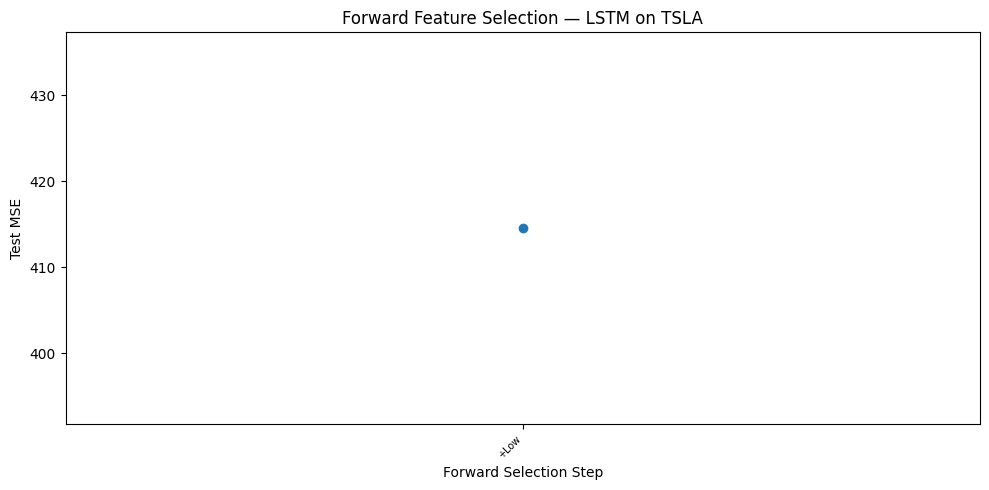

In [6]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(history)
print(results_df[['step', 'added', 'mse']].to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(range(len(history)), [h['mse'] for h in history], 'o-')
plt.xlabel('Forward Selection Step')
plt.ylabel('Test MSE')
plt.title('Forward Feature Selection — LSTM on TSLA')
plt.xticks(range(len(history)),
           [f"+{h['added']}" for h in history], rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

---
# 4. Data Preparation (using selected features)
Split **before** scaling to prevent data leakage. Use separate scalers for input features and the target column.

In [7]:
from sklearn.preprocessing import RobustScaler

feature_cols = selected          # from forward selection above
target_col   = ['Close_nxt']

split_idx = int(len(df) * TRAIN_RATIO)

train_features_raw = df[feature_cols].values[:split_idx]
test_features_raw  = df[feature_cols].values[split_idx:]
train_target_raw   = df[target_col].values[:split_idx]
test_target_raw    = df[target_col].values[split_idx:]

feature_scaler = RobustScaler()
target_scaler  = RobustScaler()

train_features = feature_scaler.fit_transform(train_features_raw)
test_features  = feature_scaler.transform(test_features_raw)
train_target   = target_scaler.fit_transform(train_target_raw)
test_target    = target_scaler.transform(test_target_raw)

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'Train: {train_features.shape}  Test: {test_features.shape}')

Feature columns (1): ['Low']
Train: (2019, 1)  Test: (505, 1)


In [8]:
def create_sequences(features, target, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_features, train_target, LOOKBACK)

test_features_padded = np.concatenate([train_features[-LOOKBACK:], test_features])
test_target_padded   = np.concatenate([train_target[-LOOKBACK:], test_target])
X_test, y_test = create_sequences(test_features_padded, test_target_padded, LOOKBACK)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')

X_train: (1959, 60, 1)  y_train: (1959,)
X_test : (505, 60, 1)  y_test : (505,)


---
# 5. Building and Training LSTM

In [9]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_67"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_134 (LSTM)                 │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_134 (Dropout)           │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_135 (LSTM)                 │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_135 (Dropout)           │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,301 (473.83 KB)

 Trainable params: 121,301 (473.83 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0296 - mae: 0.0937 - val_loss: 0.0119 - val_mae: 0.0867
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0079 - mae: 0.0509 - val_loss: 0.0082 - val_mae: 0.0716
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 0.0073 - mae: 0.0493 - val_loss: 0.0060 - val_mae: 0.0630
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - loss: 0.0062 - mae: 0.0464 - val_loss: 0.0058 - val_mae: 0.0611
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 0.0058 - mae: 0.0448 - val_loss: 0.0178 - val_mae: 0.1165
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.0099 - mae: 0.0566 - val_loss: 0.0095 - val_mae: 0.0787
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - loss: 0.0063 - mae: 0.0466 - val_loss: 0.0179 - val_mae: 0.1158
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0063 - mae: 0.0457 - val_loss: 0.0045 - val_mae: 0.0531
Epoch 9/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/ste

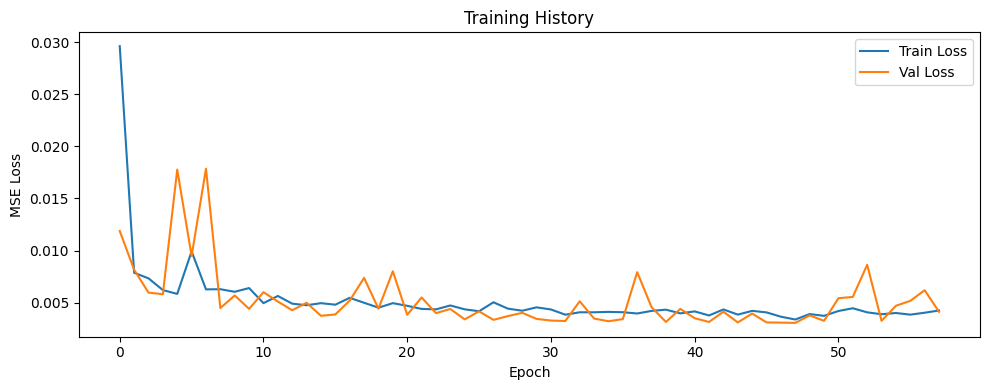

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 6. Making Predictions

In [12]:
pred_scaled = model.predict(X_test)

prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Predictions shape: (505, 1)
Actuals shape     : (505, 1)


---
# 7. Visualisation

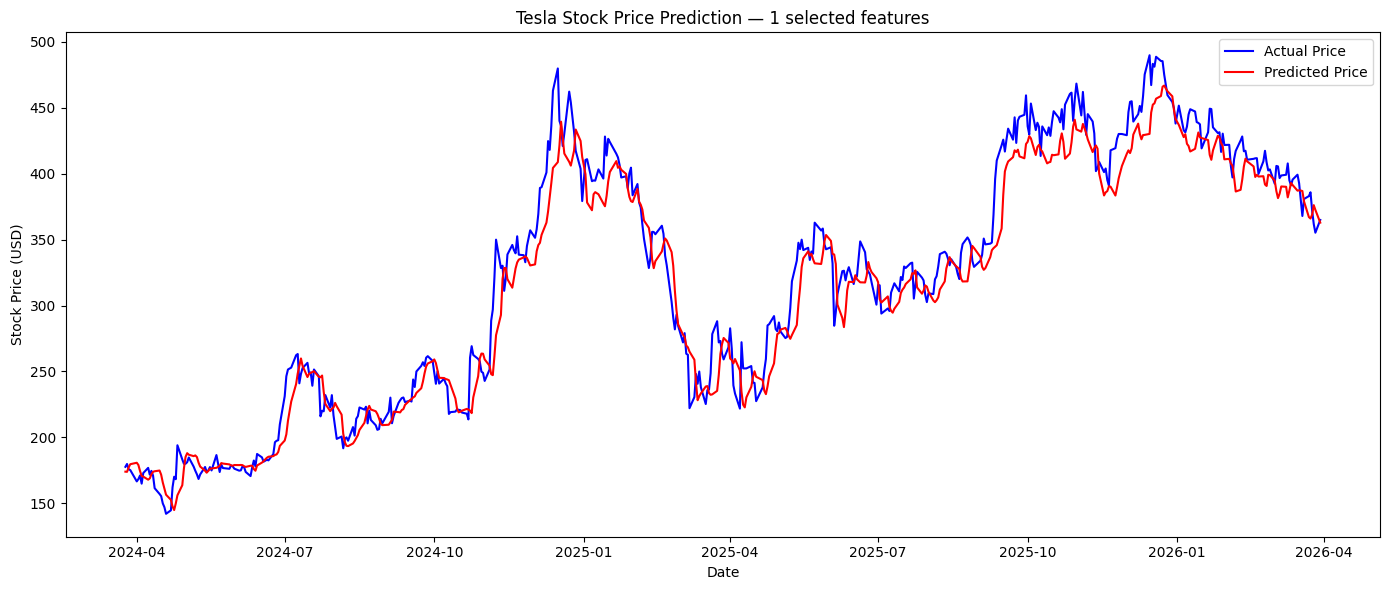

In [13]:
test_dates = df.index[split_idx:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual.flatten(), label='Actual Price', color='blue')
plt.plot(test_dates, prediction.flatten(), label='Predicted Price', color='red')
plt.title(f'Tesla Stock Price Prediction — {len(selected)} selected features')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

---
# 8. Model Evaluation

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

print('=' * 55)
print(f'LSTM with Forward-Selected Features ({len(feature_cols)})')
print(f'Features: {feature_cols}')
print('=' * 55)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 55)

LSTM with Forward-Selected Features (1)
Features: ['Low']
  MSE  : 428.6641
  RMSE : 20.7042
  MAE  : 15.6164
  MAPE : 4.90%


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


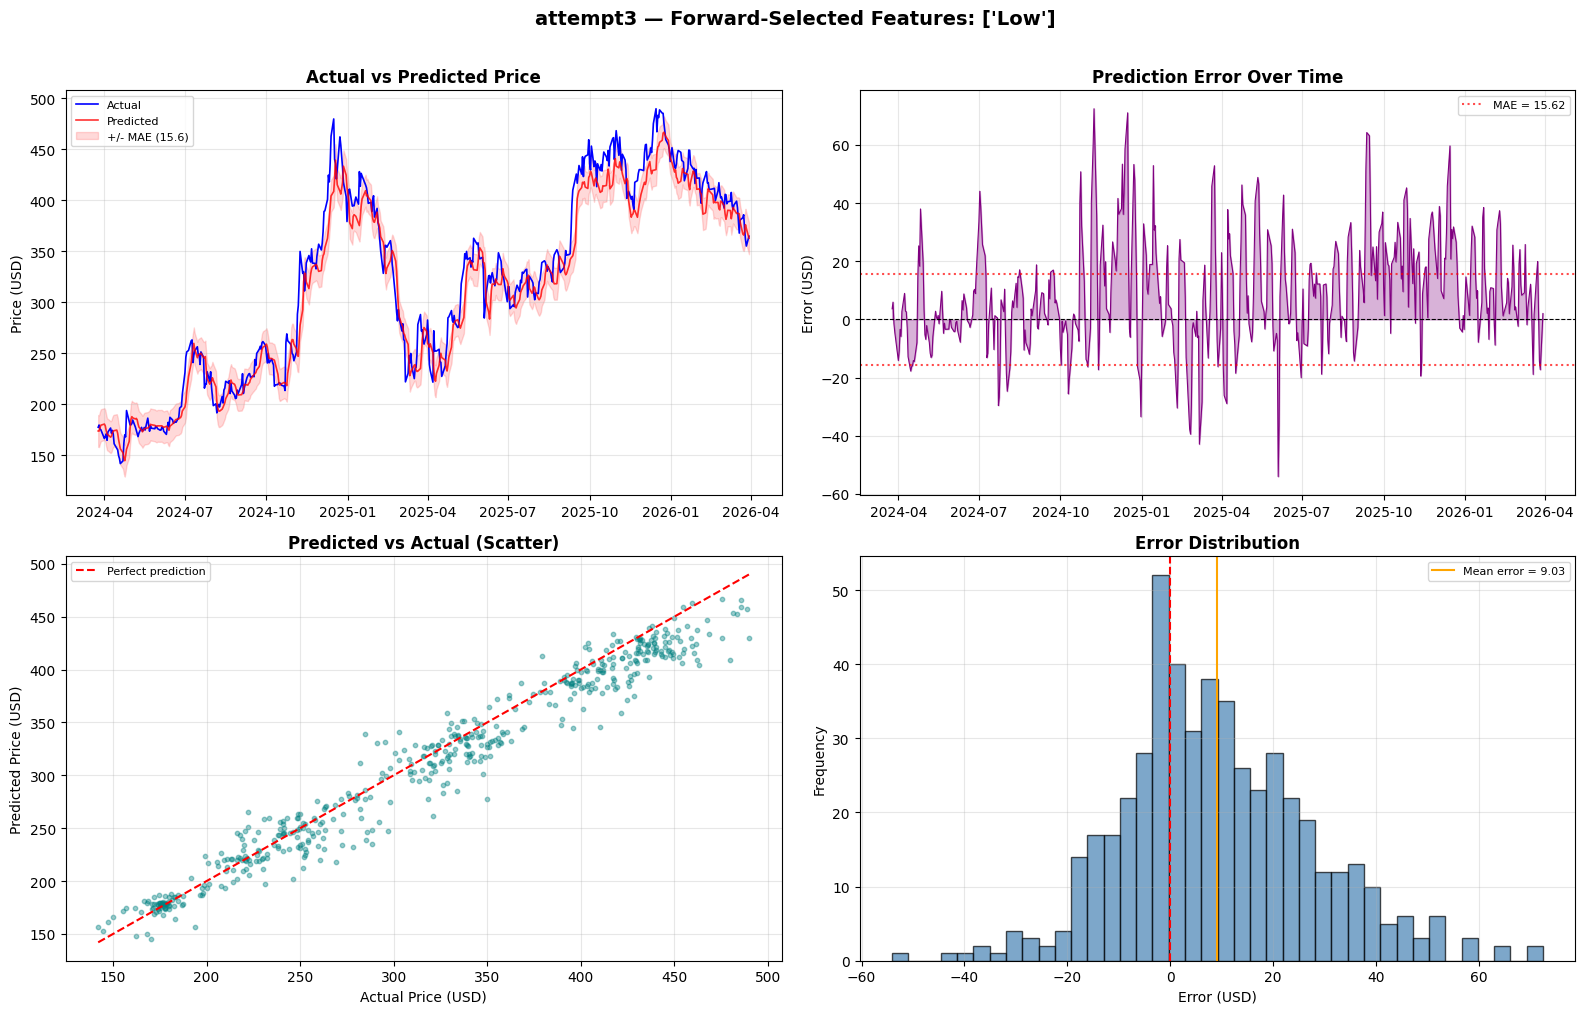

Mean Error: 9.0287  |  Std Error: 18.6319
Max Over-prediction: 72.4358  |  Max Under-prediction: -54.0471
Mean Abs % Error: 4.90%


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_scaled = model.predict(X_test)
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
test_dates = df.index[split_idx:]

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

errors = y_test_actual.flatten() - prediction.flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(test_dates, y_test_actual.flatten(), label='Actual', color='blue', linewidth=1.2)
ax.plot(test_dates, prediction.flatten(), label='Predicted', color='red', linewidth=1.2, alpha=0.8)
ax.fill_between(test_dates, prediction.flatten() - mae, prediction.flatten() + mae,
                alpha=0.15, color='red', label=f'+/- MAE ({mae:.1f})')
ax.set_title('Actual vs Predicted Price', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(test_dates, errors, color='purple', linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=mae, color='red', linestyle=':', alpha=0.7, label=f'MAE = {mae:.2f}')
ax.axhline(y=-mae, color='red', linestyle=':', alpha=0.7)
ax.fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
ax.set_title('Prediction Error Over Time', fontweight='bold')
ax.set_ylabel('Error (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test_actual.flatten(), prediction.flatten(), alpha=0.4, s=10, color='teal')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Predicted vs Actual (Scatter)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(errors, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=errors.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean error = {errors.mean():.2f}')
ax.set_xlabel('Error (USD)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(f'attempt3 — Forward-Selected Features: {feature_cols}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean Error: {errors.mean():.4f}  |  Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.max():.4f}  |  Max Under-prediction: {errors.min():.4f}')
print(f'Mean Abs % Error: {np.abs(pct_errors).mean():.2f}%')